# UCLA Neural Network Cleaned Notebook

This cleaned notebook preserves the original learning goal: classify whether a student has a higher admission chance using the UCLA admissions dataset and a neural network. It corrects small notebook issues such as project-specific comments from other datasets, unclear scaler wording, and missing test evaluation for the final `tanh` model.

## Setup

The notebook uses the modular project files in `src/` so the same preprocessing and settings are shared by the training script and Streamlit app.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from src import config
from src.data_loader import load_dataset
from src.preprocessing import preprocess_train_test, prepare_features_and_target

## Load and inspect the dataset

In [2]:
data = load_dataset()
data.head()

,Serial_No,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Admit_Chance
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [3]:
data.shape

(500, 9)

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial_No          500 non-null    int64  
 1   GRE_Score          500 non-null    int64  
 2   TOEFL_Score        500 non-null    int64  
 3   University_Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Admit_Chance       500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [5]:
data.isna().sum()

Serial_No            0
GRE_Score            0
TOEFL_Score          0
University_Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Admit_Chance         0
dtype: int64

## Target conversion

The original target `Admit_Chance` is continuous from 0 to 1. The original notebook turns this into a binary classification target using a threshold of 0.80.

In [6]:
features, target = prepare_features_and_target(data)
target.value_counts().sort_index()

Admit_Chance
0    345
1    155
Name: count, dtype: int64

## Preprocessing and train/test split

The cleaned workflow follows the notebook: drop `Serial_No`, one-hot encode `University_Rating` and `Research`, then apply `MinMaxScaler`. The scaler is fit only on the training data to avoid data leakage.

In [7]:
split_data = preprocess_train_test(data)
split_data.x_train_raw.shape, split_data.x_test_raw.shape, split_data.x_train_processed.shape, split_data.x_test_processed.shape

((400, 7), (100, 7), (400, 12), (100, 12))

In [8]:
split_data.feature_names

['GRE_Score',
 'TOEFL_Score',
 'SOP',
 'LOR',
 'CGPA',
 'University_Rating_1',
 'University_Rating_2',
 'University_Rating_3',
 'University_Rating_4',
 'University_Rating_5',
 'Research_0',
 'Research_1']

## Train the neural network

The original notebook uses `MLPClassifier` with one hidden layer of 3 neurons, batch size 50, max_iter 200, and random_state 123. The final tried activation function is `tanh`, so that model is evaluated here on both training and test data.

In [9]:
mlp = MLPClassifier(
    hidden_layer_sizes=config.HIDDEN_LAYER_SIZES,
    activation=config.FINAL_ACTIVATION,
    solver="adam",
    batch_size=config.BATCH_SIZE,
    max_iter=config.MAX_ITER,
    random_state=config.RANDOM_STATE,
)
mlp.fit(split_data.x_train_processed, split_data.y_train)

c:\Users\roman\Downloads\UCLA_Neural_Network_ML_Project\.venv312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(3,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'tanh'
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",50
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",123
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


## Evaluate the model

In [10]:
train_predictions = mlp.predict(split_data.x_train_processed)
test_predictions = mlp.predict(split_data.x_test_processed)

train_accuracy = accuracy_score(split_data.y_train, train_predictions)
test_accuracy = accuracy_score(split_data.y_test, test_predictions)

train_accuracy, test_accuracy

(0.9, 0.87)

In [11]:
confusion_matrix(split_data.y_test, test_predictions)

array([[62,  7],
       [ 6, 25]])

In [13]:
print(classification_report(split_data.y_test, test_predictions, zero_division=0))

              precision    recall  f1-score   support

           0       0.91      0.90      0.91        69
           1       0.78      0.81      0.79        31

    accuracy                           0.87       100
   macro avg       0.85      0.85      0.85       100
weighted avg       0.87      0.87      0.87       100



## Loss curve

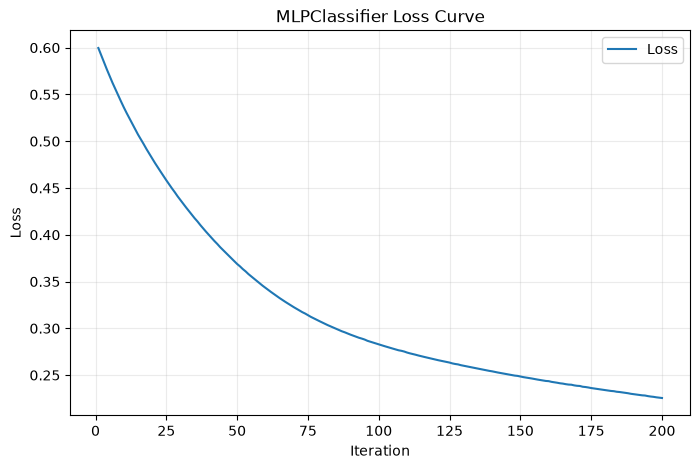

In [14]:
loss_history = pd.DataFrame({
    "iteration": range(1, len(mlp.loss_curve_) + 1),
    "loss": mlp.loss_curve_,
})

plt.figure(figsize=(8, 5))
plt.plot(loss_history["iteration"], loss_history["loss"], label="Loss")
plt.title("MLPClassifier Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

## Save the production artifacts

The full artifact-saving workflow is handled by the modular training script. Run this from the project root when you want to regenerate the saved model, preprocessing pipeline, metrics, and outputs.

In [15]:
# From the project root:
# python -m src.model_training